# Exemple d'utilisation de l'API Obspy 

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.signal as sp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt


from obspy import UTCDateTime, Stream, Inventory
from datetime import timedelta
from obspy.clients.fdsn import Client
import scipy.io.wavfile as wavfile

## Quelques fonctions utiles 

In [2]:
def get_data(data_info):
    """
    Download waveform data and metadata using ObsPy.

    Parameters
    ----------
    data_info : dict
        Dictionary containing client, network, stations, channel,
        start_time, end_time

    Returns
    -------
    st : Stream
    inv : Inventory
    """

    client = Client(data_info["client"])

    st = Stream()
    inv = Inventory()

    for sta_id in data_info["stations"]:
        try:
            st += client.get_waveforms(
                network=data_info["network"],
                station=sta_id,
                channel=data_info["channel"],
                location="*",
                starttime=UTCDateTime(data_info["start_time"]),
                endtime=UTCDateTime(data_info["end_time"]),
            )

            inv += client.get_stations(
                network=data_info["network"],
                station=sta_id,
                channel=data_info["channel"],
                level="response",
                starttime=UTCDateTime(data_info["start_time"]),
                endtime=UTCDateTime(data_info["end_time"]),
            )

        except Exception as e:
            print(f"Error with station {sta_id}: {e}")

    return st, inv

In [3]:
def apply_response_correction(
    st, inv, pre_filt=(0.05, 0.1, 100, 120), response_output="DEF", plot=True
):
    """
    Remove instrument response from stream.
    """
    st = st.copy()
    st.remove_response(
        inventory=inv,
        output=response_output,
        pre_filt=pre_filt,
        water_level=60,
        plot=plot,
    )
    return st

In [12]:
def plot_spectrogram(
    trace, nperseg=2048, overlap=0.75
):
    p0 = 1e-6
    noverlap = int(nperseg * overlap)

    f, t, Sxx = sp.stft(
        trace.data,
        fs=trace.stats.sampling_rate,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # to get Pa**2 / Hz (assuming input is given in Pa)
    )
    # ATTENTIOn : à vérifier pour les unités en fonction du paramètre scaling je ne pas sur que ce soit le bon 
    # De manière général il faut faire attention lorsque l'on veut calculer des niveaux absolus sur des spectros ... 
    Sxx_db = 10 * np.log10(
        np.abs(Sxx)
    )  # dB re 1 Pa**2 / Hz (assuming input is given in Pa)
    Sxx_db += 20 * np.log10(1 / p0)  # dB re 1uPa**2 / Hz
    clabel = r"dB re 1$\mu$Pa$^2$ / Hz"

    #  Associated datetime vector
    tt_datetime = pd.date_range(
        trace.stats.starttime.datetime,
        trace.stats.starttime.datetime + timedelta(seconds=t[-1]),
        freq=f"{t[1]-t[0]:.3f}s",
        inclusive="both",
    )

    fig = plt.figure()
    plt.pcolormesh(
        tt_datetime,
        f,
        Sxx_db,
        cmap="magma",
        vmin=np.percentile(Sxx_db, 20),
        vmax=np.percentile(Sxx_db, 95),
    )

    formatter = mdates.DateFormatter("%H:%M")
    plt.gca().xaxis.set_major_formatter(formatter)
    formatter = mdates.DateFormatter("%H:%M")
    plt.gca().xaxis.set_major_formatter(formatter)
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    plt.gca().xaxis.set_major_locator(locator)
    plt.setp(plt.gca().get_xticklabels(), rotation=15, ha="right")

    plt.colorbar(label=clabel)
    plt.xlabel("Time")
    plt.ylabel("Frequency [Hz]")
    plt.title(f"{trace.id}")

    return fig

## Un exemple sur Alparay 

In [5]:
fmt = "%Y-%m-%d_%H-%M-%S"
start_time = pd.to_datetime("2017-07-03_10-00-00", format=fmt)
end_time = start_time + pd.Timedelta(minutes=30)
print(f"Processing data from {start_time} to {end_time}...")

data_info = {
    "client": "RESIF",
    "network": "Z3",
    "stations": [
        "A416A",
        "A419A",
        "A425A",
    ],
    "channel": "BHZ",
    "start_time": start_time,
    "end_time": end_time,
}

Processing data from 2017-07-03 10:00:00 to 2017-07-03 10:30:00...


In [6]:
# Chargement des données depuis le serveur 
st, inv = get_data(data_info)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\obspy\clients\fdsn\client.py:257: ObsPyDeprecationWarning: RESIF is now EPOSFR. Webservices and client will be shutdown in 2026. Please consider changing the FDSN client short URL to 'EPOSFR'.
  warnings.warn(msg, ObsPyDeprecationWarning)


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


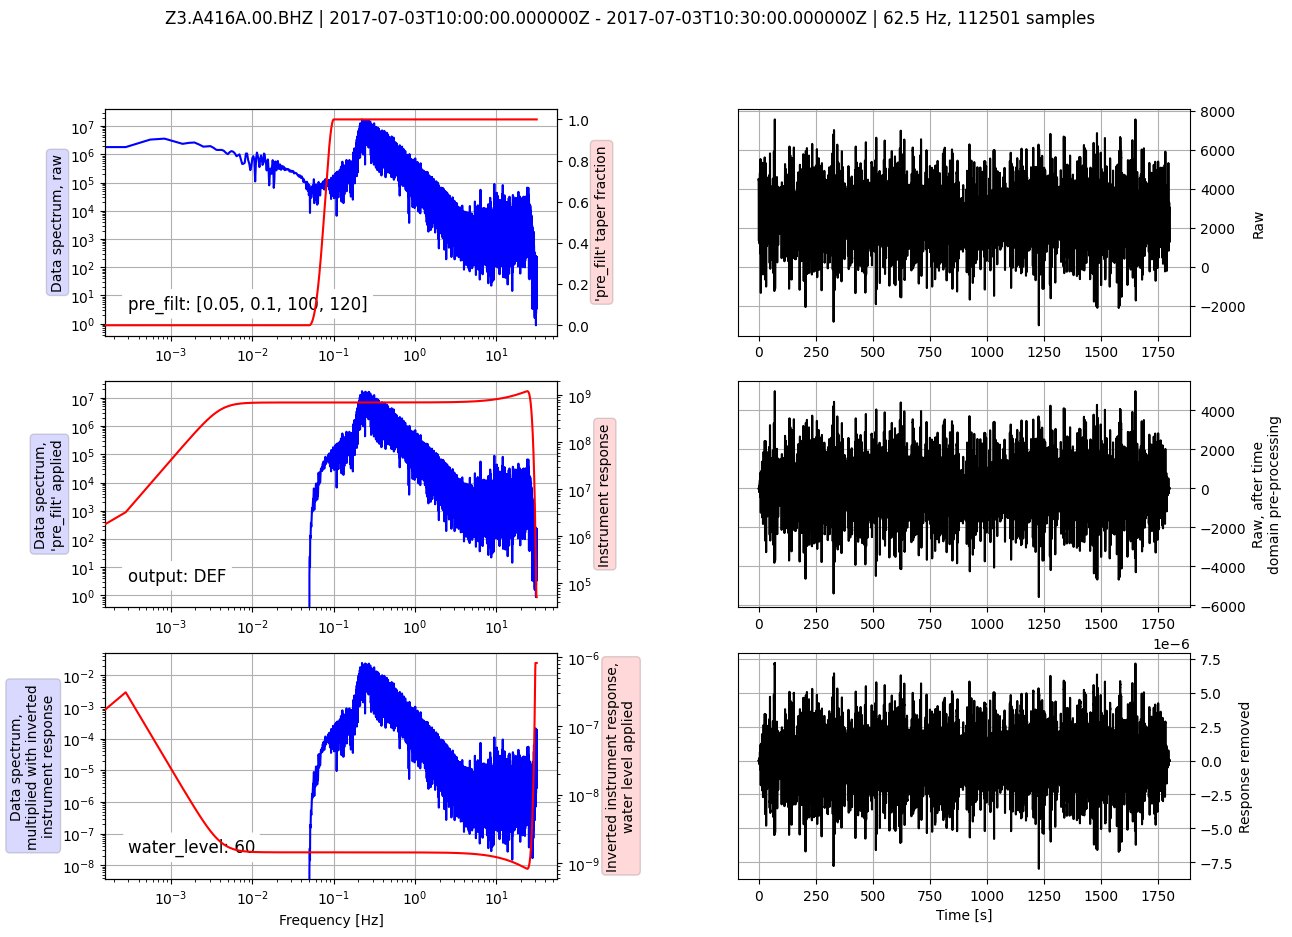

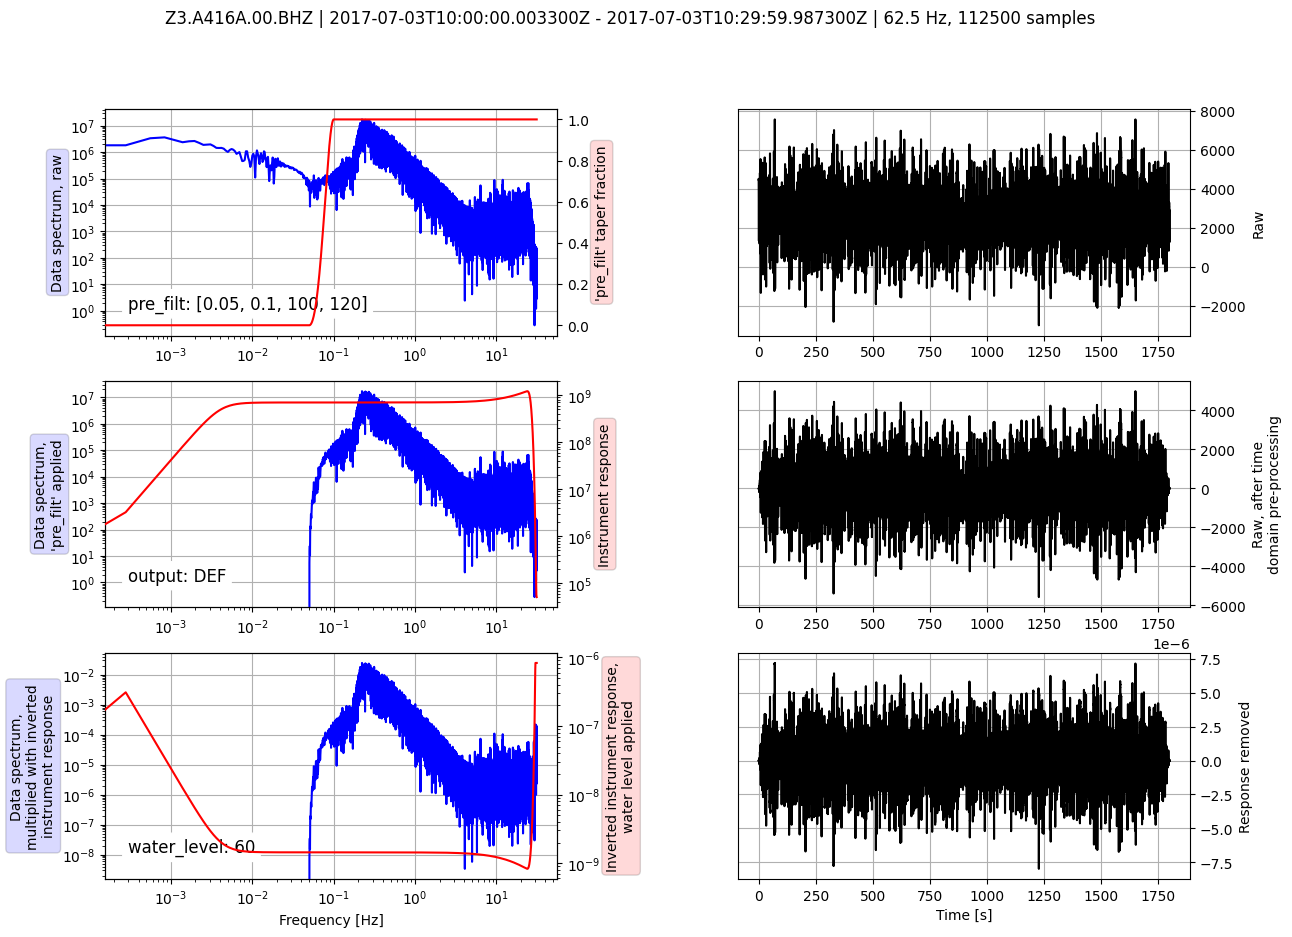

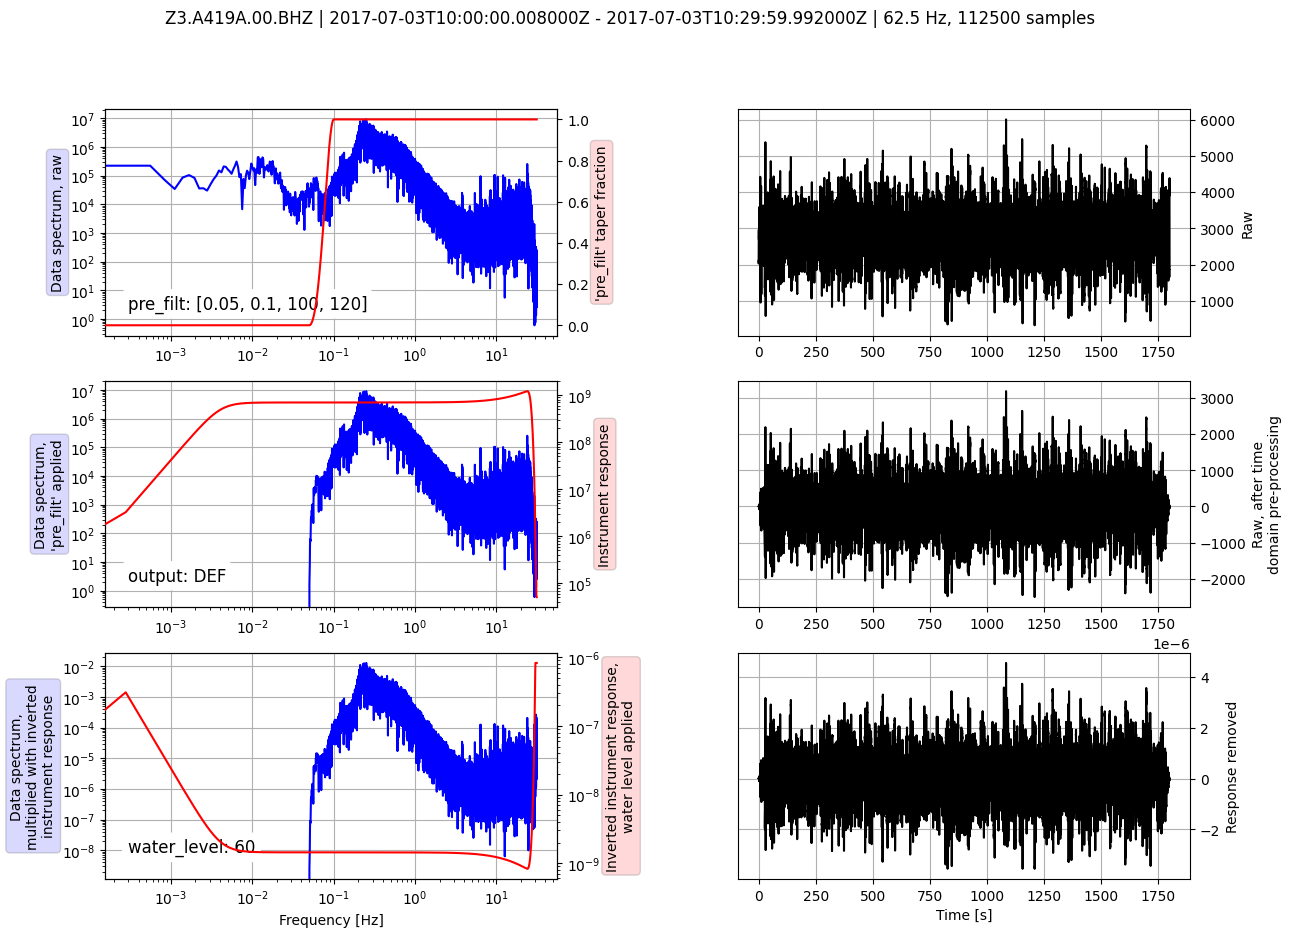

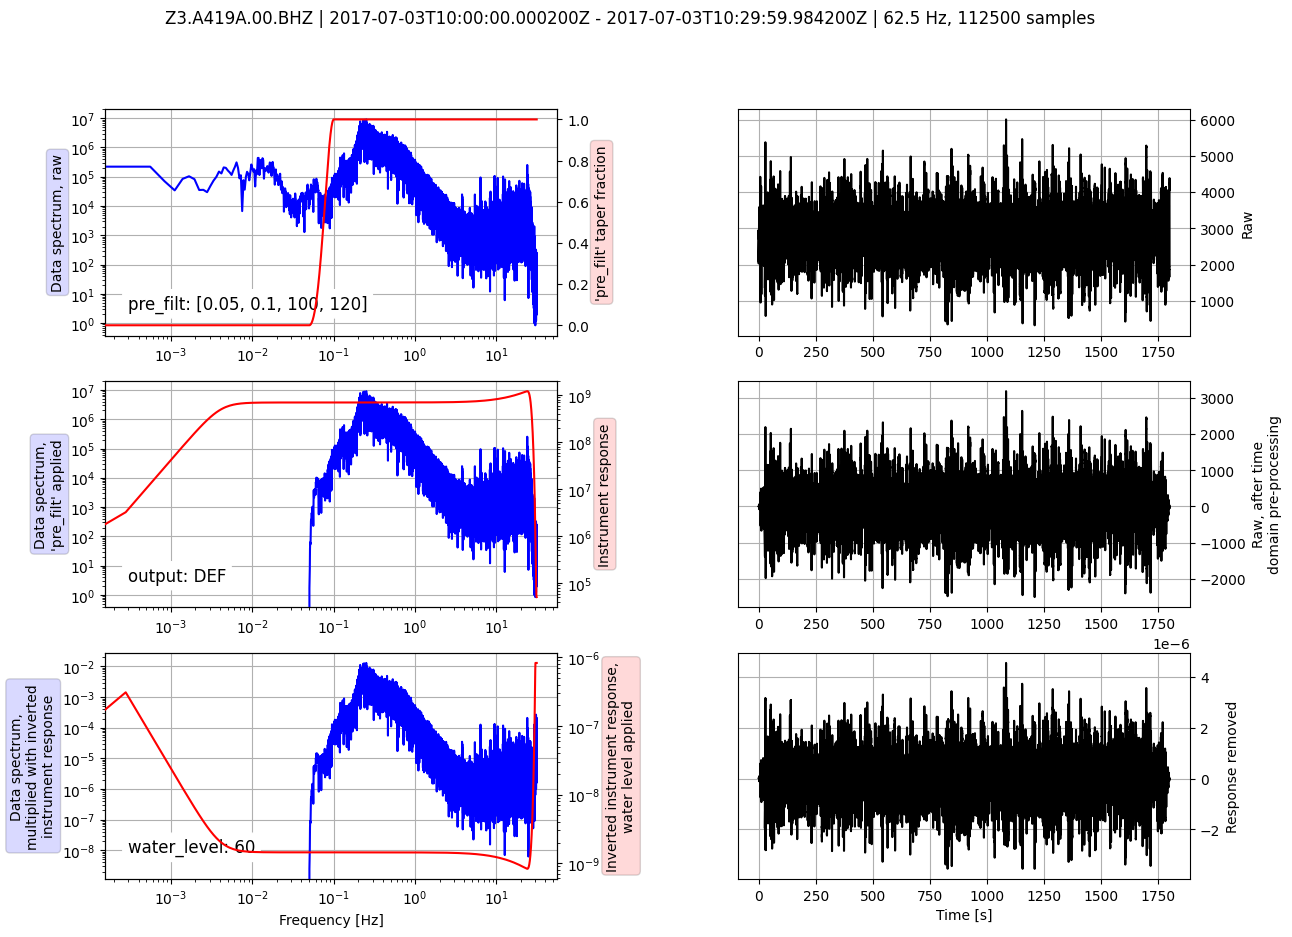

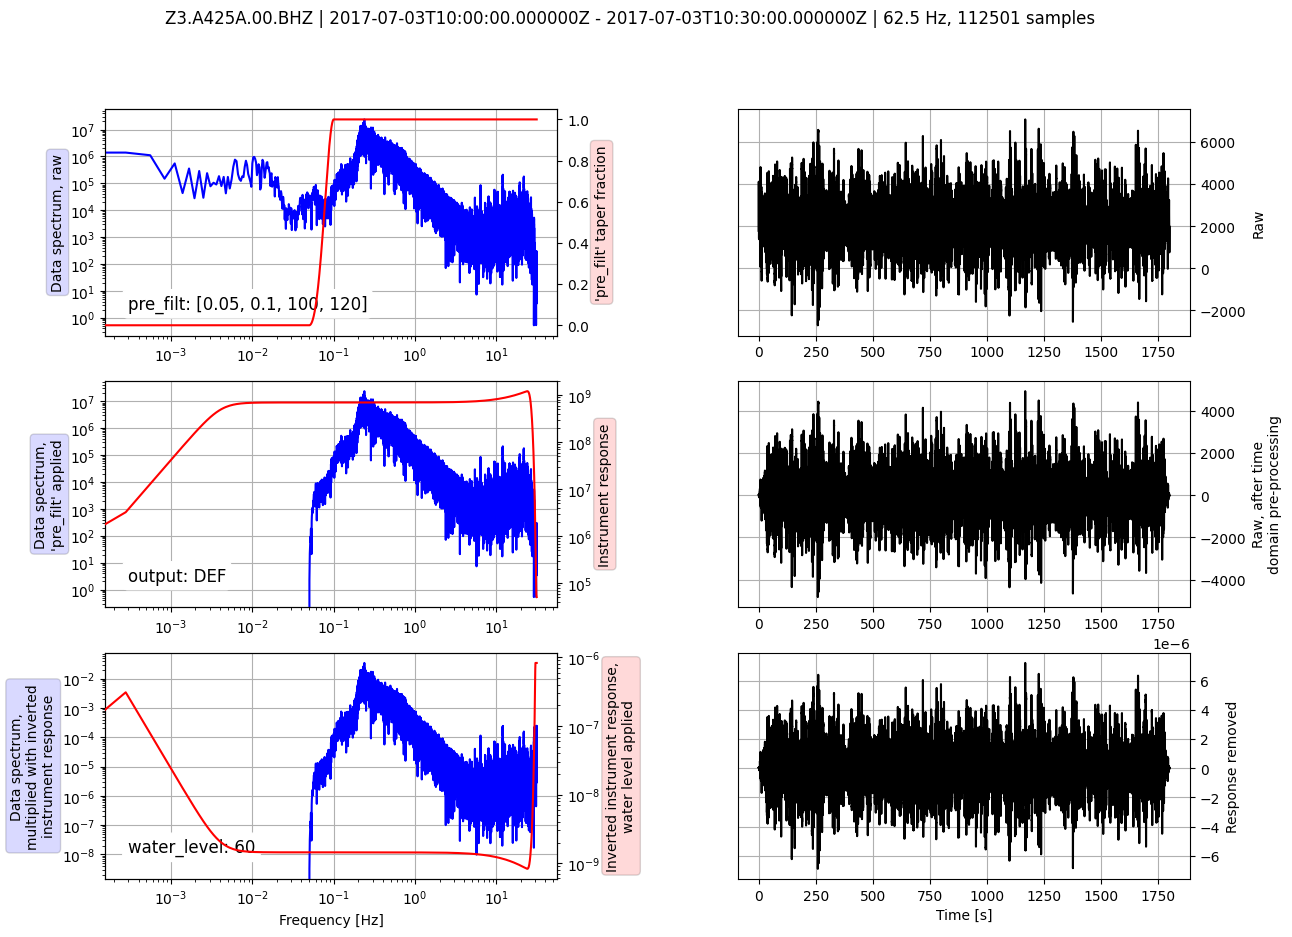

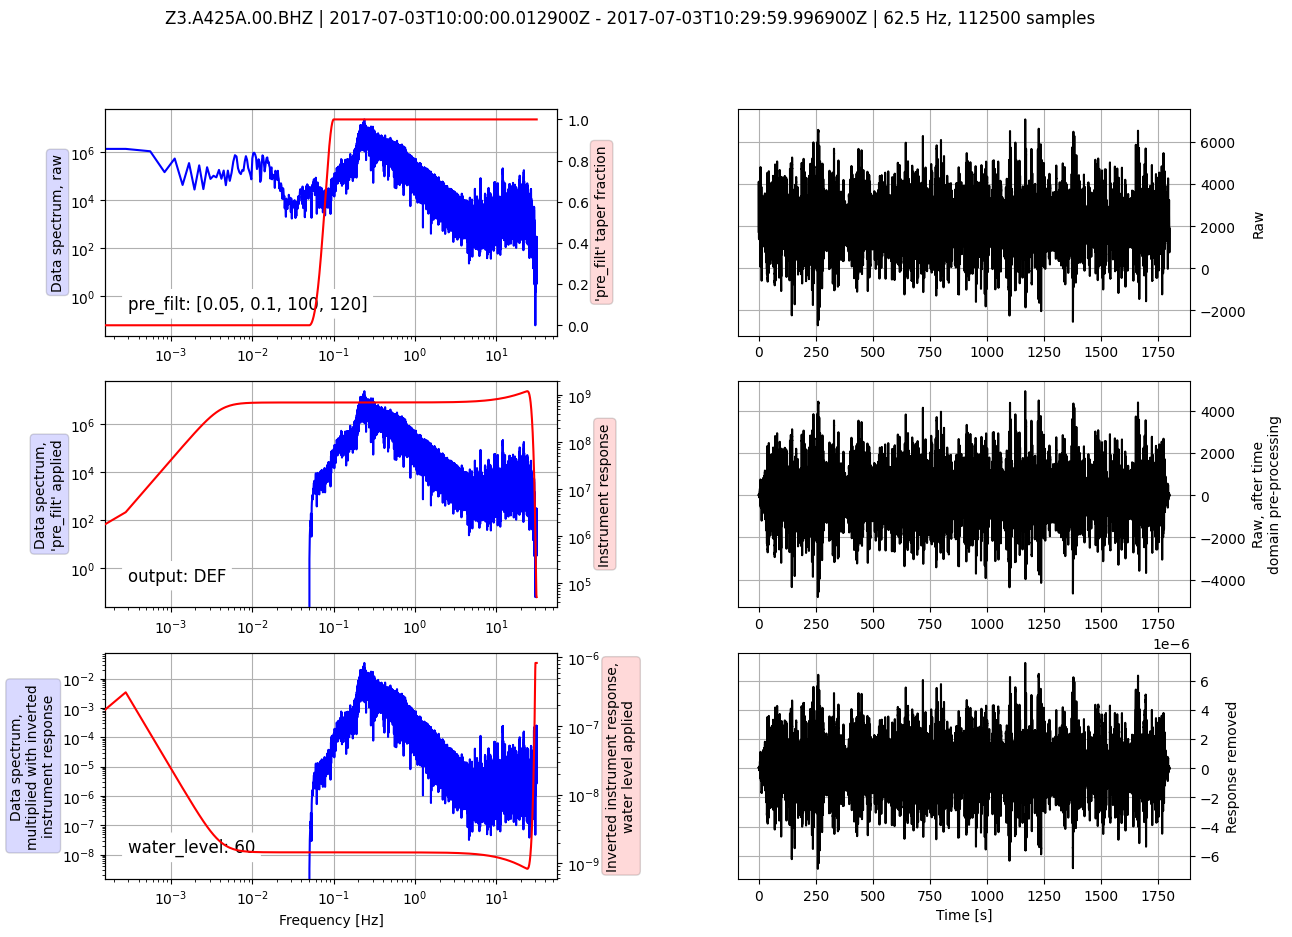

In [7]:
# Correction de la réponse 
st = apply_response_correction(st, inv)

In [8]:
# Les métadonnées sont stockés dans les objects Inventory inv 
for net in inv:
    for sta in net:
        print(f"Station {sta.code}")
        print("  Latitude:", sta.latitude)
        print("  Longitude:", sta.longitude)
        print("  Elevation:", sta.elevation)
        print("  Start:", sta.start_date)
        print("  End:", sta.end_date)

# Build filename
fmt = "%Y-%m-%d_%H-%M-%S"
date_start = pd.to_datetime(start_time).strftime(fmt)
date_end = (pd.to_datetime(end_time)).strftime(fmt)
fname = f"signal_{data_info['network']}_{data_info['channel']}_{date_start}_{date_end}_"  # on sauvegarde les signaux corriges dans un fichier .wav

# Pour sauvegarder les wavs
# root_wav = "data/wav"
# for tr in st:
#     fpath = os.path.join(root_wav, fname + f"{tr.stats.station}.wav")

#     # Save corrected signal
#     wavfile.write(
#         fpath,
#         int(tr.meta.sampling_rate),
#         tr.data,
#     )

Station A416A
  Latitude: 42.6479
  Longitude: 6.9627
  Elevation: -2631.0
  Start: 2017-06-26T10:00:00.000000Z
  End: 2018-02-17T01:52:00.000000Z
Station A419A
  Latitude: 43.2913
  Longitude: 8.602
  Elevation: -2585.0
  Start: 2017-06-25T10:00:00.000000Z
  End: 2018-02-19T04:27:00.000000Z
Station A425A
  Latitude: 42.6478
  Longitude: 8.0738
  Elevation: -2708.0
  Start: 2017-06-24T11:00:00.000000Z
  End: 2018-02-21T04:00:00.000000Z


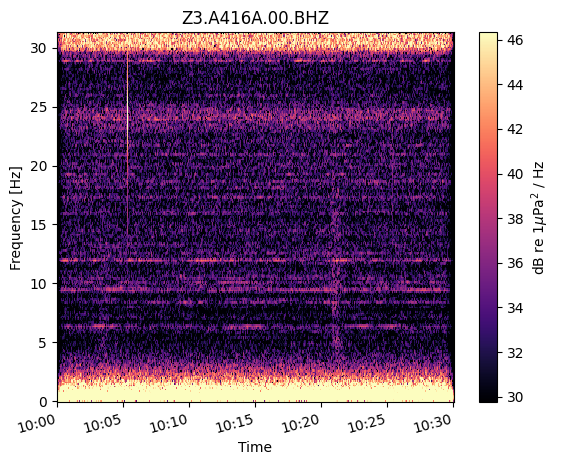

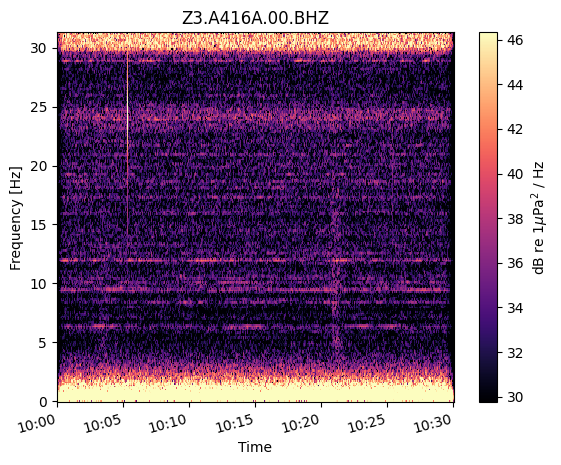

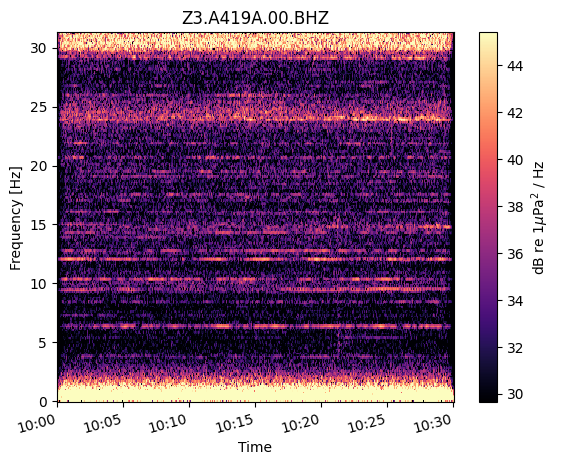

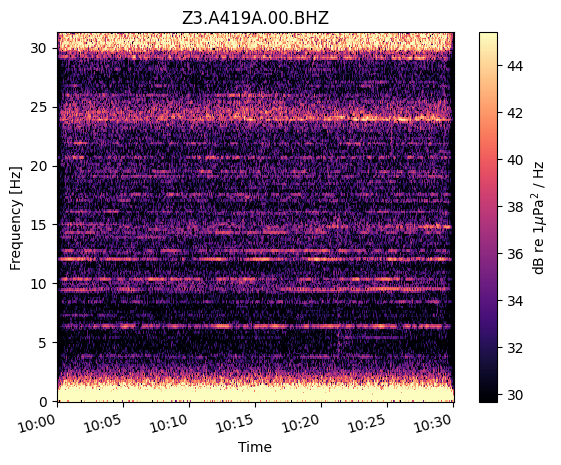

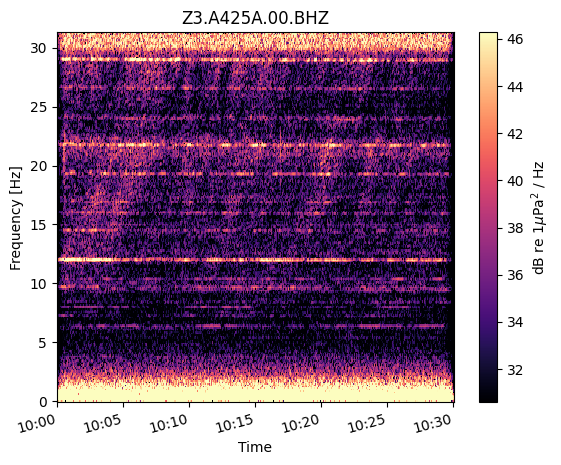

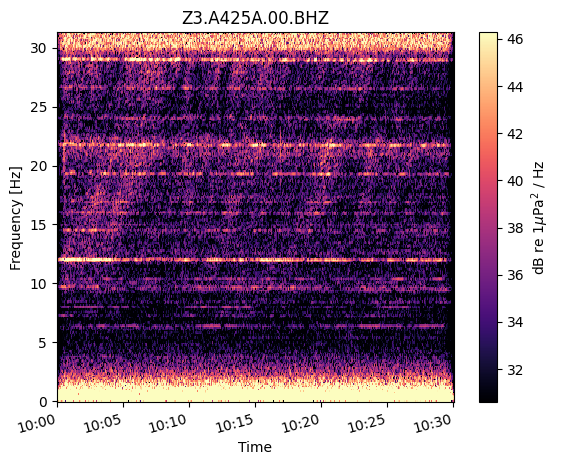

In [13]:
# Les données sont dans les Trace tr
for itr, tr in enumerate(st):

    # Spectro des données pour check que ça ressemble à du signal
    plot_spectrogram(tr, nperseg=512, overlap=0.75)